# dudas pal grupete:

Será importante guardar info sobre si algo es persona o no? (a partir de los qid). La pregunta viene de que de esta manera puede ser más fácil (se me olvido que estaba diciendo)

In [1]:
import os
import pathlib
import math

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 


In [2]:
data_dir = '../Datasets'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv') and not f.startswith('triplets')]
print(files)

# Material de trabajo:
dfs_dict = {file_name: pd.read_csv(os.path.join(data_dir, file_name)) for file_name in files}
big_df = pd.read_csv(os.path.join(data_dir, "triplets.csv"))

['republica_dominicana.csv', 'peru.csv', 'entity_types', 'merge.py', 'chile.csv', 'mexico.csv', 'costa_rica.csv', 'paraguay.csv', 'triplets.csv', 'nicaragua.csv', 'README.md', 'usa.csv', 'panama.csv', 'ecuador.csv', 'argentina.csv', 'venezuela.csv', 'colombia.csv', 'guatemala.csv', 'el_salvador.csv', 'honduras.csv', 'cuba.csv']


### 1) Tripletas por archivo

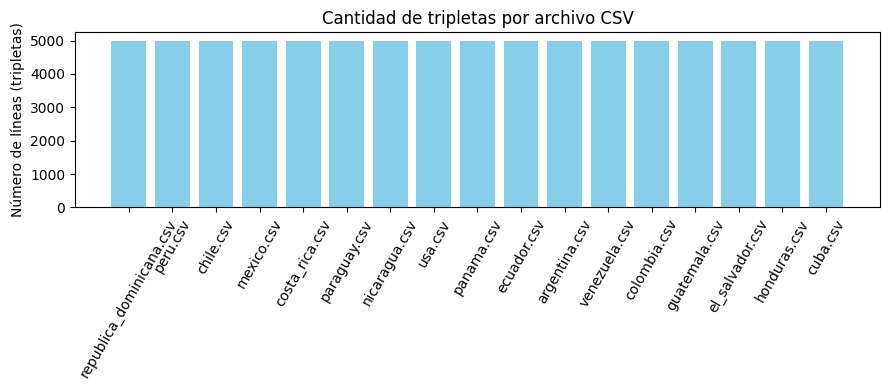

In [3]:
line_counts = {}
for file_name, df in dfs_dict.items():
    line_counts[file_name] = len(df)

plt.figure(figsize=(9, 4))
plt.bar(line_counts.keys(), line_counts.values(), color="skyblue")
plt.ylabel("Número de líneas (tripletas)")
plt.title("Cantidad de tripletas por archivo CSV")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

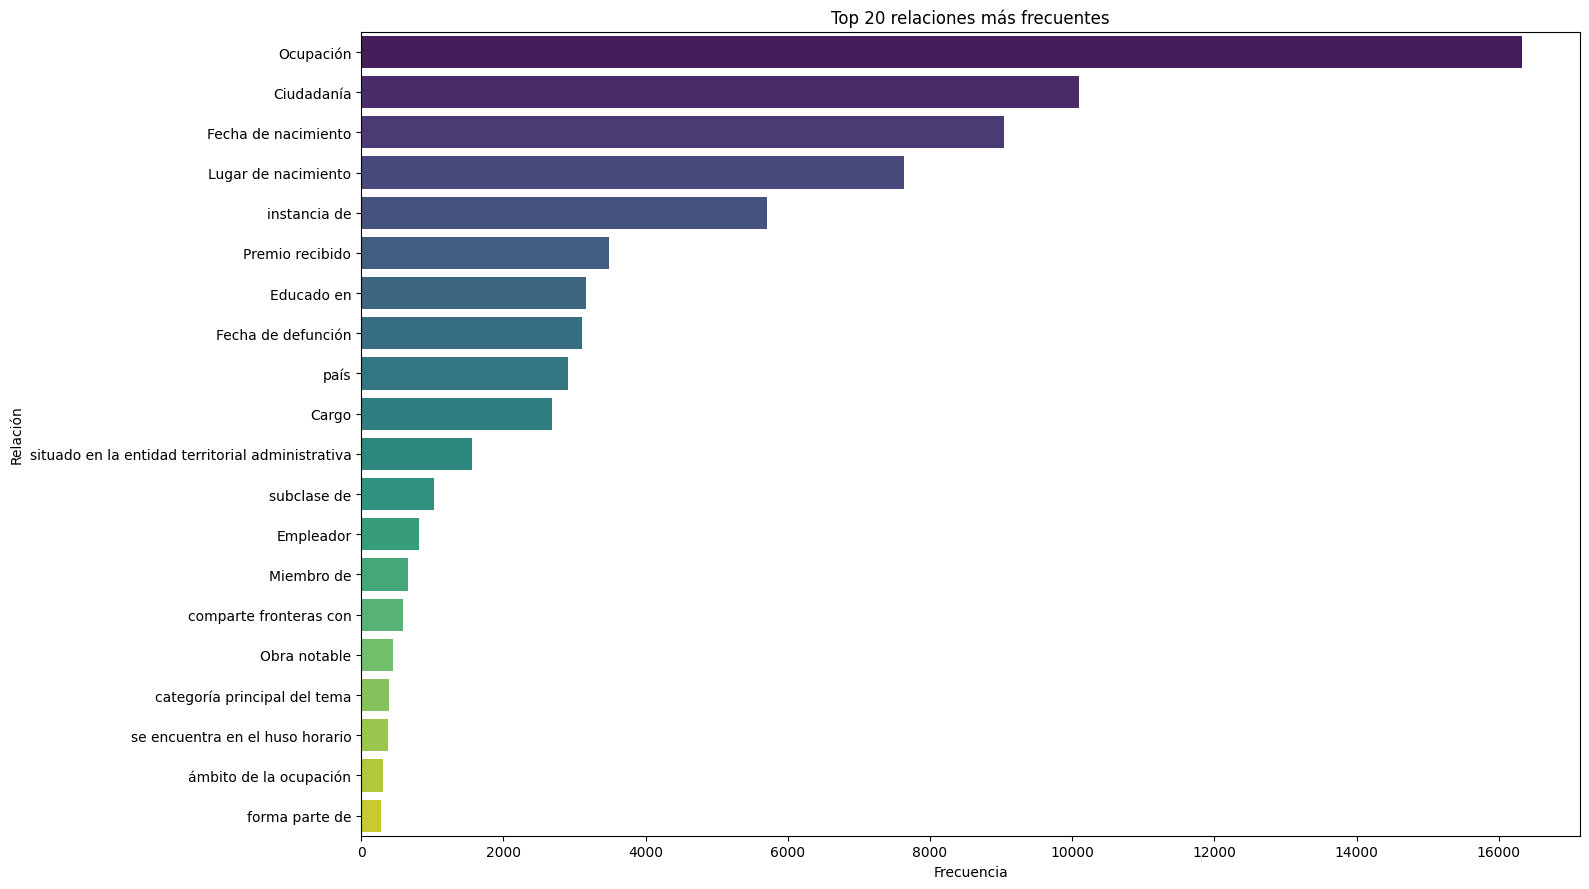

In [4]:
relation_counts = big_df['relacion'].value_counts().reset_index()

top_n = 20
plt.figure(figsize=(16, 9))
sns.barplot(
    data=relation_counts.head(top_n),
    y='relacion',
    x='count',
    hue='relacion',
    palette='viridis',
    legend=False
)
plt.xlabel('Frecuencia')
plt.ylabel('Relación')
plt.title(f'Top {top_n} relaciones más frecuentes')
plt.tight_layout()
plt.show()


### 2) Relaciones promedio por entidad

In [10]:
def relations_per_entity_hist_all():
    total_files = len(dfs_dict)

    max_x = 0
    max_y = 0
    data_dict = {}

    # Precalcula grados por archivo y máximos globales
    for name, df in dfs_dict.items():
        entity_degrees = df['entidad'].value_counts()
        data_dict[name] = entity_degrees
        max_x = max(max_x, entity_degrees.max())
        max_y = max(max_y, entity_degrees.value_counts().max())

    cols = 3 if total_files >= 3 else total_files
    rows = math.ceil(total_files / cols) if total_files > 0 else 1
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if total_files > 1 else [axes]

    for i, name in enumerate(dfs_dict.keys()):
        sns.histplot(data_dict[name], bins=30, kde=False, ax=axes[i])
        axes[i].set_xmargin(0)  # opcional para ajustar margen
        axes[i].set_xlim(0, max_x * 1.05)     # 5% extra
        axes[i].set_yscale('log')              # coincide con la etiqueta
        axes[i].set_ylim(1, max_y * 1.2)       # margen superior
        axes[i].set_xlabel('Relaciones por entidad')
        axes[i].set_ylabel('Frecuencia (log)')
        axes[i].set_title(name.replace('.csv', ''))

    # Elimina ejes sobrantes si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [12]:
relations_per_entity_hist_all()

UnboundLocalError: cannot access local variable 'file' where it is not associated with a value

### 4)

In [7]:
folder_entity_types = data_dir + "/" + "entity_types"
files_entity_types = os.listdir(folder_entity_types)
roots_entitity_type = [folder_entity_types + "/" + file for file in files_entity_types if file_name.endswith('.csv')]
entity_types_dfs = {files_entity_types[i].split(".")[0]: pd.read_csv(roots_entitity_type[i], sep="\t") for i in range(len(roots_entitity_type))}

In [8]:
usa = entity_types_dfs['usa']
instancia_list = list(usa.instancia_de)

In [9]:
instancia_list

['ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'ser humano',
 'Distritos de la ciudad de Nueva York',
 'ocupación, profesión musical',
 'país, república federal, superpotencia internacional, república constitucional, estado soberano, república democrática',
 'escuela secundaria superior',
 'película',
 'sede d